# Robustness of Accessibility
## Notebook 2b/4 - (Optional) visualize graph construction

In [1]:
import geopandas as gpd 
from shapely.geometry import Point 
from shapely.ops import unary_union 
import osmnx as ox 
import folium 


#### Add rivers for visualization of the evacuation area

In [2]:
# use name to get bounds
import os
from pathlib import Path

p = Path.cwd().resolve()
while not (p / "css_geodata_service").exists() and p.parent != p:
    p = p.parent
os.chdir(p)
print("CWD reset to repo root:", Path.cwd())


from css_geodata_service.robustness_of_accessibility.examples.notebooks.notebook_utils import (
    RoaNotebookConfig,
    get_roa_cache_path,
    get_roa_outputs_path,
)

cache_dir: Path = get_roa_cache_path()
output_dir: Path = get_roa_outputs_path()
place_name = RoaNotebookConfig.place_name
place_gdf = ox.geocode_to_gdf(place_name)

CWD reset to repo root: C:\Users\baiis\Desktop\roa_fopra
Working dir set to: C:\Users\baiis\Desktop\roa_fopra
Working dir set to: C:\Users\baiis\Desktop\roa_fopra


(6.551792, 49.6986005, 6.7471503, 49.8571154)


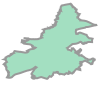

In [3]:
# 1. From the GeoDataFrame
if len(place_gdf) > 1:
    raise RuntimeError(f"gdf for {place_name} has multiple entries, could not safely deterine bounds")
boundary_geom = place_gdf.geometry.iloc[0]  # usually the first geometry

# 2. If it’s a MultiPolygon, merge the parts into one

if boundary_geom.geom_type == "MultiPolygon":
    boundary_geom = unary_union(boundary_geom)
elif boundary_geom.geom_type != "Polygon":
    raise RuntimeError(f"Could not combine boundary due to unexpected data structure {boundary_geom.geom_type}")
print(boundary_geom.bounds)
boundary_geom

In [4]:
tags_rivers = {"water": ["river"]}
rivers = ox.features_from_polygon(polygon=boundary_geom, tags=tags_rivers)

tags_rivers_line = {"waterway": ["river"]}
waterways = ox.features_from_polygon(polygon=boundary_geom, tags=tags_rivers_line)

In [5]:
# Evacuation circle around bomb discovery point 
bomb_lon = 6.660376 
bomb_lat = 49.741604 
radius_m = 1000 
 
# Punkt in WGS84
pt = gpd.GeoSeries([Point(bomb_lon, bomb_lat)], crs="EPSG:4326")

# Projektion nach UTM (meter-basiert) und Buffer dort
pt_utm = pt.to_crs("EPSG:32632")  # Trier liegt in UTM Zone 32N
evacuation_area_utm = pt_utm.buffer(radius_m)

# Zurück nach WGS84 für Plot/Folium
evacuation_area_gdf = evacuation_area_utm.to_crs("EPSG:4326")
evacuation_area = evacuation_area_gdf.iloc[0]

c:\Users\baiis\Desktop\roa_fopra\.venv\Lib\site-packages\pyproj\transformer.py:816: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self._transformer._transform_point(


In [6]:
# load networks to visualize
road_network = ox.load_graphml(cache_dir / f"network/drive_graph_{place_name}.graphml")
road_network_removed = ox.load_graphml(cache_dir / f"network/drive_graph_removed{place_name}.graphml")
road_network_remaining = ox.load_graphml(cache_dir / f"network/drive_graph_remaining_{place_name}.graphml")

## Plot the evacuation area and the networks

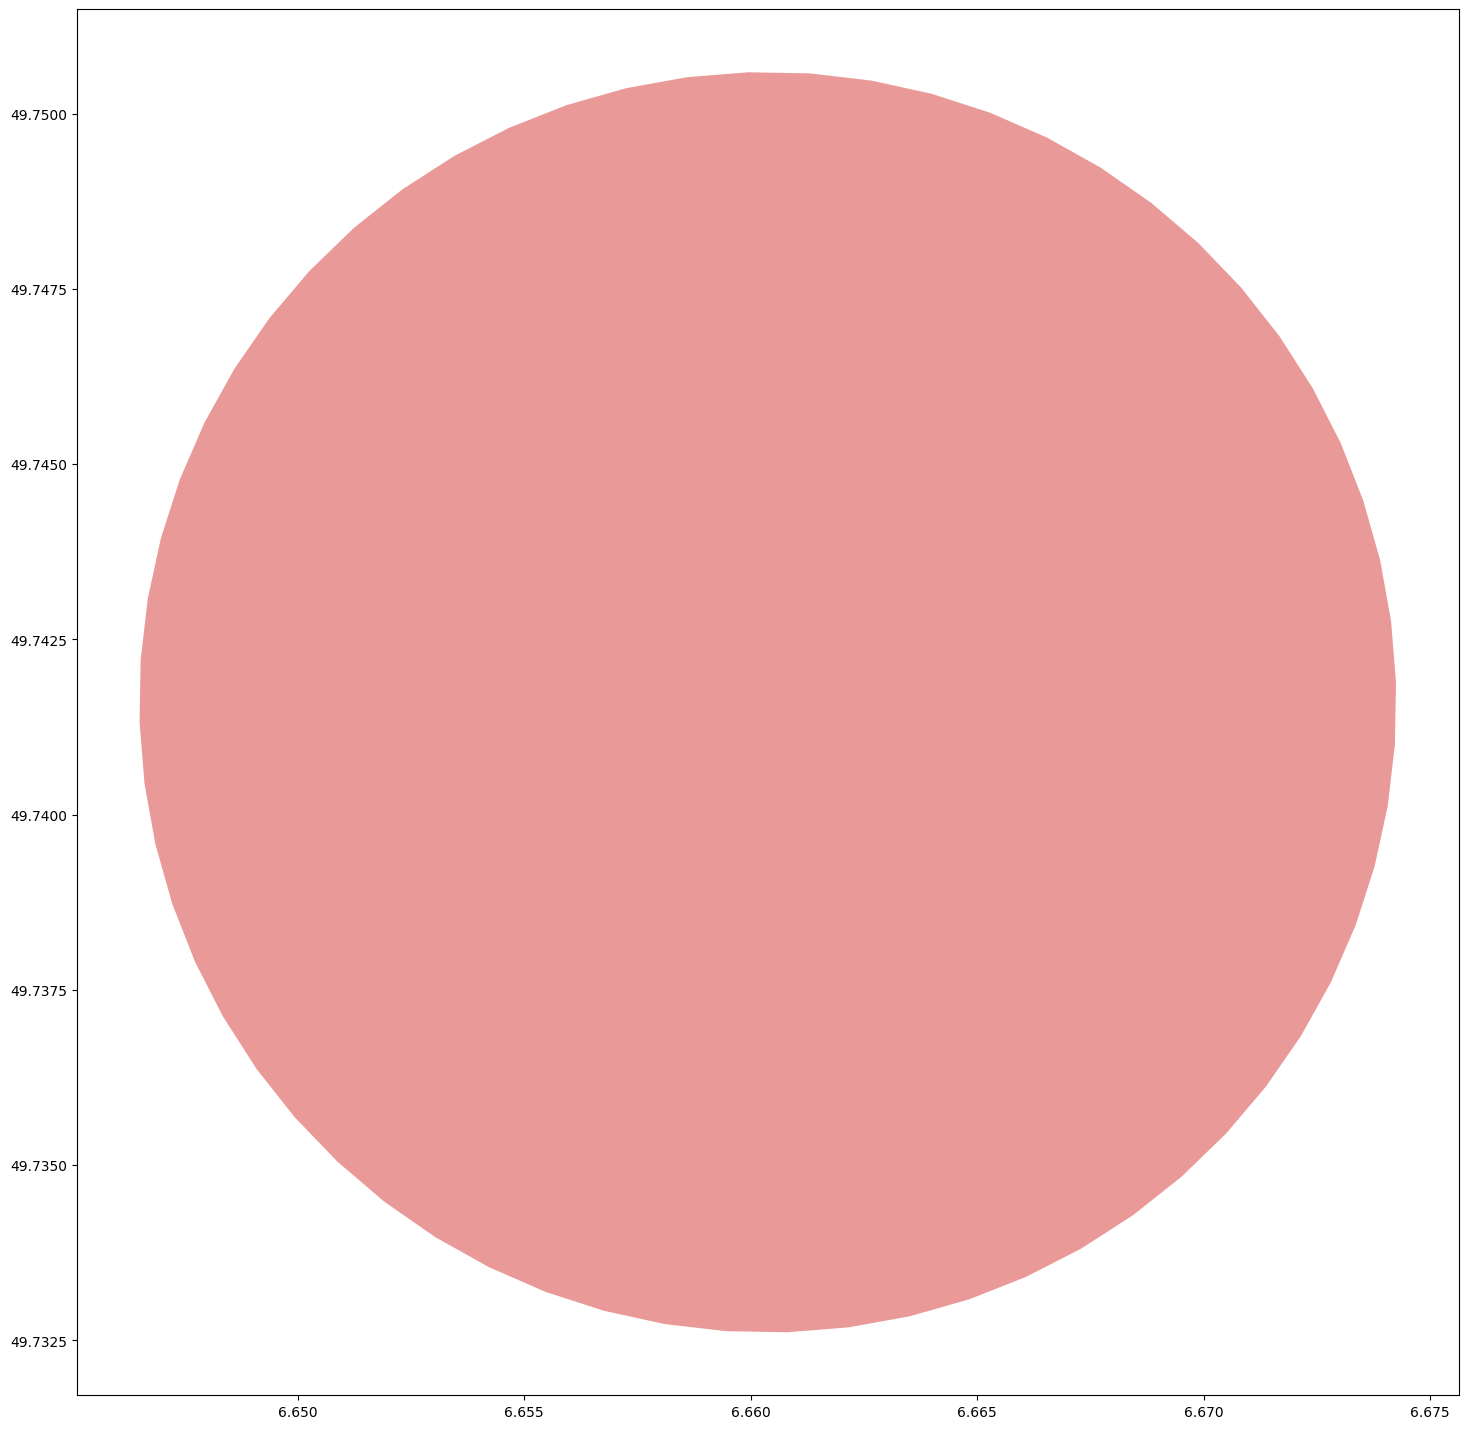

In [7]:
ax_evacuation_boundary = evacuation_area_gdf.plot(figsize=(18, 18), color='#CC000066', zorder=10) 


In [8]:
ax_evacuation_boundary

<Axes: >

In [9]:
# add waterways/rivers as background context for orientation
ax_evacuation_boundary = waterways.plot(figsize=(18, 18), ax=ax_evacuation_boundary, zorder=0) 
 
ax_evacuation_boundary = rivers.plot(figsize=(18, 18), ax=ax_evacuation_boundary, zorder=0) 


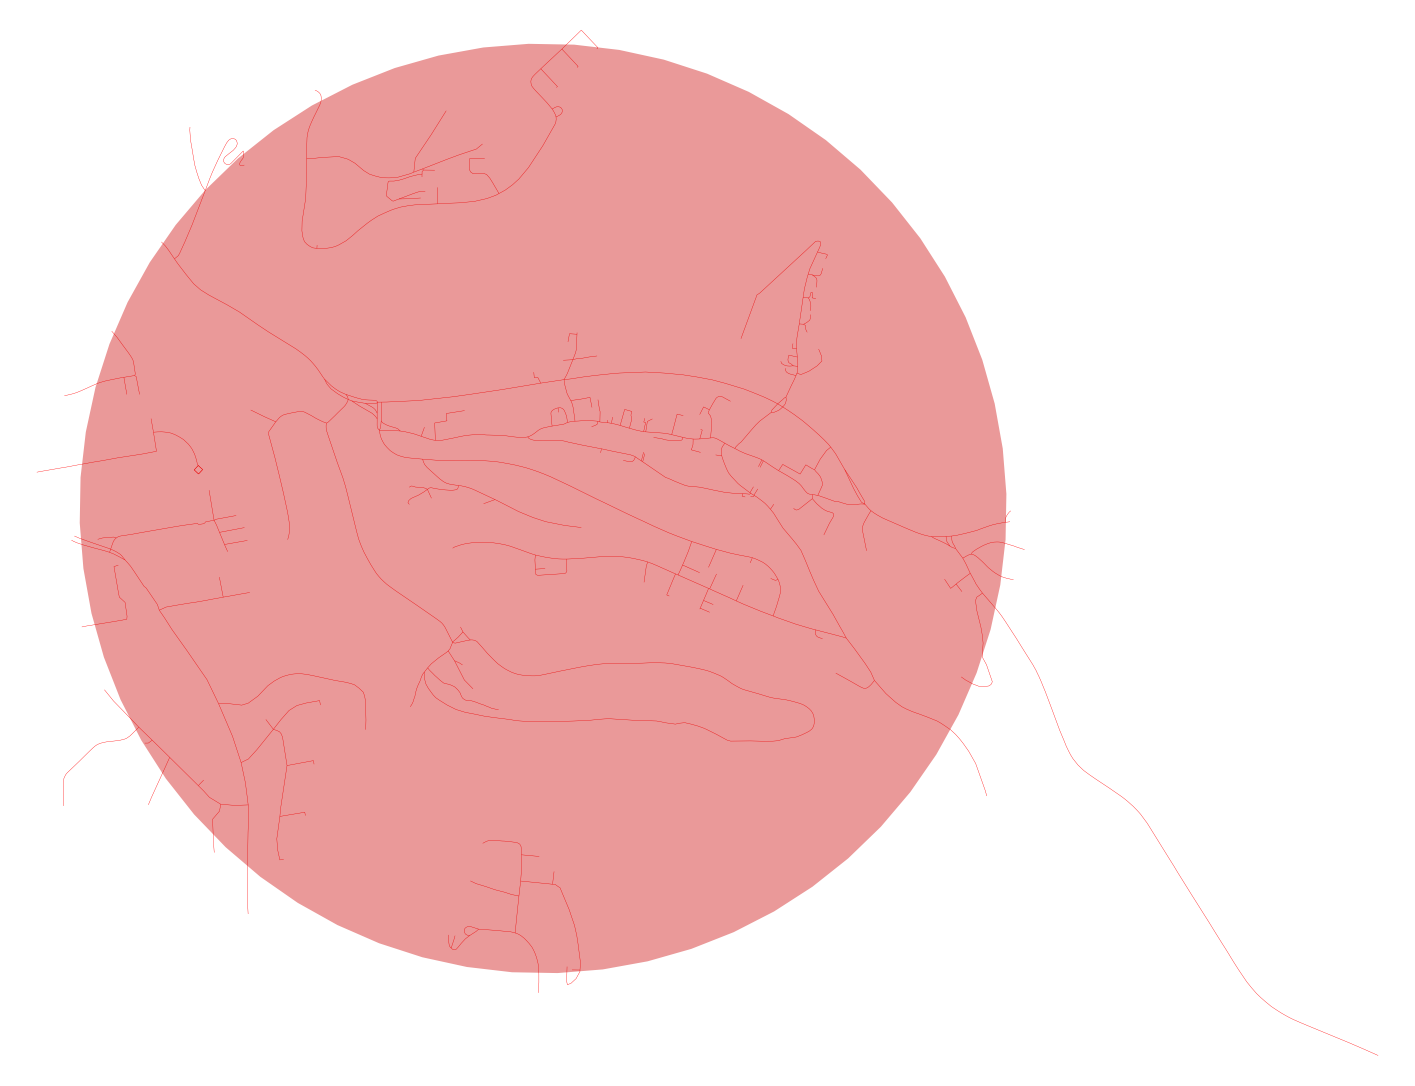

In [10]:
fig_1, ax_evacuation_boundary = ox.plot_graph( 
    road_network_removed, figsize=(18, 18), node_size=0, edge_color='red', edge_linewidth=0.25, ax=ax_evacuation_boundary 
) 
 
fig_1 


In [11]:
# add un_affected_network to the ax 
fig_2, ax_evacuation_boundary = ox.plot_graph( 
    road_network_remaining, 
    figsize=(18, 18), 
    node_size=0, 
    edge_color='black', 
    edge_linewidth=0.25, 
    show=False, 
    close=False, 
    ax=ax_evacuation_boundary, 
) 


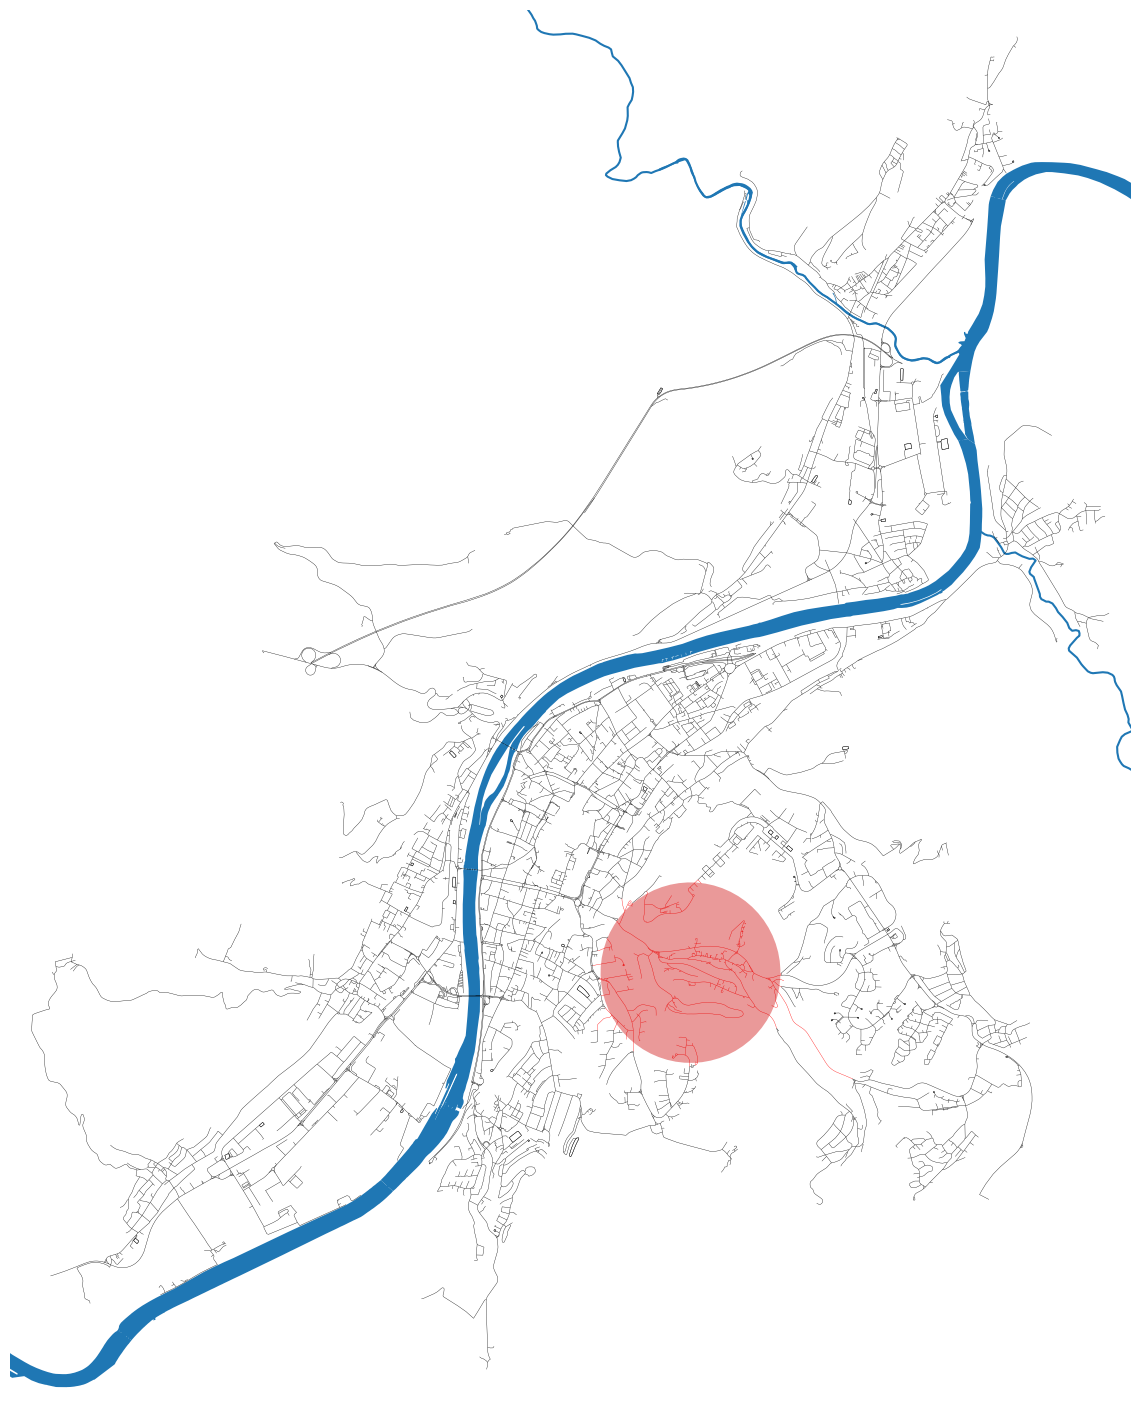

In [12]:
fig_2

In [13]:
# plt.savefig(f'output/evacuation_area_{place_name}.png', dpi=150) 
fig_2.savefig(output_dir / 'plots' / f'affected_network_area_{place_name}.png', dpi=300) 


## Create an interactive map with folium containing the evacuation area

### Disclaimer about coordinates:
- Shapely uses: (lon, lat)
- Folium / leaflet uses (lat, lon)

In [14]:
evacuation_map = folium.Map(location=[49.745, 6.65], zoom_start=13, tiles='CartoDB positron') 


In [15]:
# geo_j = polygon1.simplify(tolerance=0.001).to_json() 
geo_json_evacuation = folium.GeoJson( 
    data=evacuation_area_gdf, style_function=lambda x: {'fillColor': 'red', 'color': 'red'} 
) 
folium.Popup('Evacuation area').add_to(geo_json_evacuation) 
 
geo_json_evacuation.add_to(evacuation_map) 


In [16]:
evacuation_map